In [1]:
#AI - POWERED COMMODITY PRICE FORECASTING USING ML, DL, NLP & LLM
#1.Import libraries

In [2]:
import pandas as pd
import numpy as np

In [3]:
#2.Load dataset

In [4]:
gold = pd.read_csv("XAU_1d_data.csv", sep=";")
silver = pd.read_csv("silver_prices_data.csv")
oil = pd.read_csv("CL_in_daily_new.csv")
news = pd.read_csv("all-data.csv",encoding="latin1")

In [5]:
#3.Data understanding

In [6]:
print("Gold:", gold.shape)
print("Silver:", silver.shape)
print("Oil:", oil.shape)
print("News:", news.shape)

Gold: (5531, 6)
Silver: (2513, 7)
Oil: (10708, 7)
News: (4845, 2)


In [7]:
gold.head()

,Date,Open,High,Low,Close,Volume
0,2004.06.11 00:00,384.0,384.8,382.8,384.1,272
1,2004.06.14 00:00,384.3,385.8,381.8,382.8,1902
2,2004.06.15 00:00,382.8,388.8,381.1,388.6,1951
3,2004.06.16 00:00,387.1,389.8,382.6,383.8,2014
4,2004.06.17 00:00,383.6,389.3,383.0,387.6,1568


In [8]:
silver.head()

,Date,Price,Close,High,Low,Open,Volume
0,2016-01-19,14.110,14.110,14.065,14.065,3,NaN
1,2016-01-20,14.147,14.147,14.147,14.147,1,NaN
2,2016-01-21,14.083,14.083,14.083,14.083,2,NaN
3,2016-01-22,14.043,14.290,14.043,14.290,7,NaN
4,2016-01-25,14.240,14.240,14.095,14.095,8,NaN


In [9]:
oil.head()

,datetime,symbol,open,high,low,close,volume
0,1983-03-29 23:00:00,NYMEX:CL1!,29.25,29.56,29.01,29.40,0.0
1,1983-03-30 23:00:00,NYMEX:CL1!,29.40,29.60,29.25,29.27,0.0
2,1983-04-03 23:00:00,NYMEX:CL1!,29.30,29.70,29.29,29.44,0.0
3,1983-04-04 23:00:00,NYMEX:CL1!,29.50,29.80,29.50,29.71,0.0
4,1983-04-05 23:00:00,NYMEX:CL1!,29.90,29.92,29.65,29.90,0.0


In [10]:
news.head()

,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [123]:
gold.info()
silver.info()
oil.info()
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531 entries, 0 to 5530
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5531 non-null   datetime64[ns]
 1   Open    5531 non-null   float64       
 2   High    5531 non-null   float64       
 3   Low     5531 non-null   float64       
 4   Close   5531 non-null   float64       
 5   Volume  5531 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 259.4 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2513 non-null   datetime64[ns]
 1   Price   2513 non-null   float64       
 2   Close   2513 non-null   float64       
 3   High    2513 non-null   float64       
 4   Low     2513 non-null   float64       
 5   Open    2513 non-null   int64         
dtypes: datet

In [12]:
gold.isnull().sum()
silver.isnull().sum()
oil.isnull().sum()
news.isnull().sum()

neutral                                                                                                                            0
According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .    0
dtype: int64

In [13]:
#4.Data cleaning and preprocessing

In [14]:
silver= silver.drop(columns=['Volume'])

In [15]:
silver.head()

,Date,Price,Close,High,Low,Open
0,2016-01-19,14.110,14.110,14.065,14.065,3
1,2016-01-20,14.147,14.147,14.147,14.147,1
2,2016-01-21,14.083,14.083,14.083,14.083,2
3,2016-01-22,14.043,14.290,14.043,14.290,7
4,2016-01-25,14.240,14.240,14.095,14.095,8


In [16]:
news.columns

Index(['neutral', 'According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .'], dtype='object')

In [17]:
news = pd.read_csv(
    "all-data.csv",
    encoding="latin1",
    header=None,
    names=["Sentiment", "News"]
)

In [18]:
news.head()

,Sentiment,News
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [19]:
gold['Date'] = pd.to_datetime(gold['Date'])

silver['Date'] = pd.to_datetime(silver['Date'])

oil['datetime'] = pd.to_datetime(oil['datetime'])

In [20]:
gold.info()
silver.info()
oil.info()
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531 entries, 0 to 5530
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5531 non-null   datetime64[ns]
 1   Open    5531 non-null   float64       
 2   High    5531 non-null   float64       
 3   Low     5531 non-null   float64       
 4   Close   5531 non-null   float64       
 5   Volume  5531 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 259.4 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2513 non-null   datetime64[ns]
 1   Price   2513 non-null   float64       
 2   Close   2513 non-null   float64       
 3   High    2513 non-null   float64       
 4   Low     2513 non-null   float64       
 5   Open    2513 non-null   int64         
dtypes: datet

In [21]:
#5.Exploratory data analysis

In [22]:
news['Sentiment'].value_counts()

Sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

In [23]:
#5.1 News Sentiment distribution

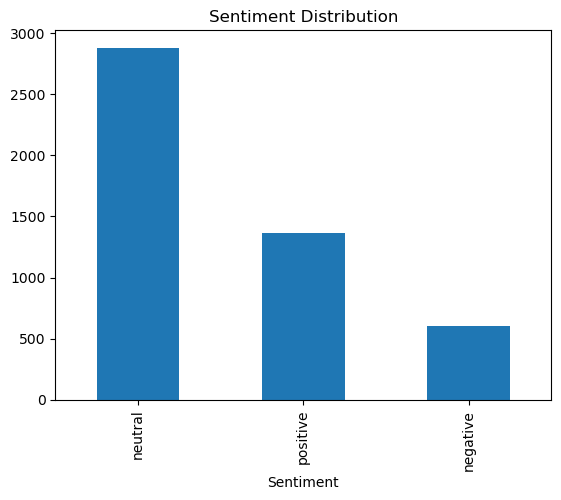

In [24]:
import matplotlib.pyplot as plt

news['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

In [25]:
#6.NLP Preprocessing

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
news['Sentiment_Label'] = le.fit_transform(news['Sentiment'])

news.head()

,Sentiment,News,Sentiment_Label
0,neutral,"According to Gran , the company has no plans t...",1
1,neutral,Technopolis plans to develop in stages an area...,1
2,negative,The international electronic industry company ...,0
3,positive,With the new production plant the company woul...,2
4,positive,According to the company 's updated strategy f...,2


In [27]:
#6.1 Text cleaning

In [28]:
news['clean_text'] = news['News'].str.lower()

news[['News','clean_text']].head()

,News,clean_text
0,"According to Gran , the company has no plans t...","according to gran , the company has no plans t..."
1,Technopolis plans to develop in stages an area...,technopolis plans to develop in stages an area...
2,The international electronic industry company ...,the international electronic industry company ...
3,With the new production plant the company woul...,with the new production plant the company woul...
4,According to the company 's updated strategy f...,according to the company 's updated strategy f...


In [29]:
import re

news['clean_text'] = news['clean_text'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', str(x))
)

news['clean_text'].head()

0    according to gran  the company has no plans to...
1    technopolis plans to develop in stages an area...
2    the international electronic industry company ...
3    with the new production plant the company woul...
4    according to the company s updated strategy fo...
Name: clean_text, dtype: object

In [30]:
#6.2 TF - IDF Vectorization

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(news['clean_text'])

y = news['Sentiment_Label']

print(X.shape)

(4846, 5000)


In [32]:
# 7. Machine Learning Model

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
# 7.1 Logistic Regression Model

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [36]:
# 7.2 Sentiment Prediction

In [37]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 2 1 1 1 2 1 1 1]


In [38]:
# 7.3 Model Evaluation

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7701030927835052


In [40]:
# 7.4 Classification Report

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.50      0.65       110
           1       0.75      0.96      0.84       571
           2       0.81      0.51      0.62       289

    accuracy                           0.77       970
   macro avg       0.83      0.65      0.70       970
weighted avg       0.79      0.77      0.75       970



In [42]:
#7.5 Confusion Matrix

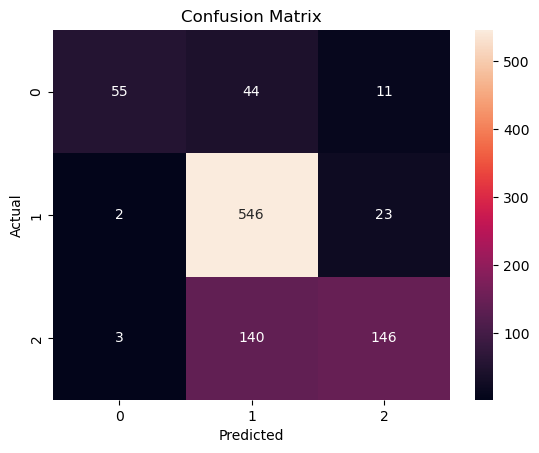

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
#7.6 XGBoost Classifier

In [45]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [46]:
#7.7 XGBoost Accuracy

In [47]:
from sklearn.metrics import accuracy_score

acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", acc_xgb)

XGBoost Accuracy: 0.7855670103092783


In [48]:
#7.8 XGBoost Classification Report

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.79      0.56      0.66       110
           1       0.78      0.93      0.85       571
           2       0.80      0.58      0.68       289

    accuracy                           0.79       970
   macro avg       0.79      0.69      0.73       970
weighted avg       0.79      0.79      0.78       970



In [50]:
#8. Deep Learning (LSTM Model)

In [51]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [52]:
#8.1 Tokenization

In [53]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(news['clean_text'])

X_seq = tokenizer.texts_to_sequences(news['clean_text'])

X_pad = pad_sequences(X_seq, maxlen=100)

y = news['Sentiment_Label']

In [54]:
#8.2 Train Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
#8.3 Build LSTM Model

In [57]:
model = Sequential()

model.add(Embedding(input_dim=5000,
                    output_dim=64,
                    input_length=100))

model.add(LSTM(64))

model.add(Dense(3, activation='softmax'))

C:\Users\kirut\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [117]:
#8.4 Compile Model

In [119]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [121]:
#8.4.1 Model Summary

In [125]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [127]:
#8.5 Train LSTM Model

In [129]:
history = model.fit(
    X_train_dl,
    y_train_dl,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_dl, y_test_dl)
)

Epoch 1/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.6029 - loss: 0.9313 - val_accuracy: 0.6732 - val_loss: 0.7482
Epoch 2/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7135 - loss: 0.6597 - val_accuracy: 0.7423 - val_loss: 0.6316
Epoch 3/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.8614 - loss: 0.3861 - val_accuracy: 0.7515 - val_loss: 0.6781
Epoch 4/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9368 - loss: 0.1914 - val_accuracy: 0.7443 - val_loss: 0.7273
Epoch 5/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9635 - loss: 0.1264 - val_accuracy: 0.7505 - val_loss: 0.8616


In [131]:
#8.6 LSTM Evaluation

In [133]:
loss, accuracy = model.evaluate(X_test_dl, y_test_dl)

print("LSTM Accuracy:", accuracy)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7607 - loss: 0.8652
LSTM Accuracy: 0.7505154609680176


In [135]:
#8.7 LSTM Prediction

In [137]:
y_pred_dl = model.predict(X_test_dl)

import numpy as np
y_pred_dl = np.argmax(y_pred_dl, axis=1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [139]:
#8.8 LSTM Classification Report

In [141]:
from sklearn.metrics import classification_report

print(classification_report(y_test_dl, y_pred_dl))

              precision    recall  f1-score   support

           0       0.75      0.58      0.66       110
           1       0.80      0.84      0.82       571
           2       0.65      0.65      0.65       289

    accuracy                           0.75       970
   macro avg       0.73      0.69      0.71       970
weighted avg       0.75      0.75      0.75       970



In [143]:
#8.9 LSTM Confusion Matrix

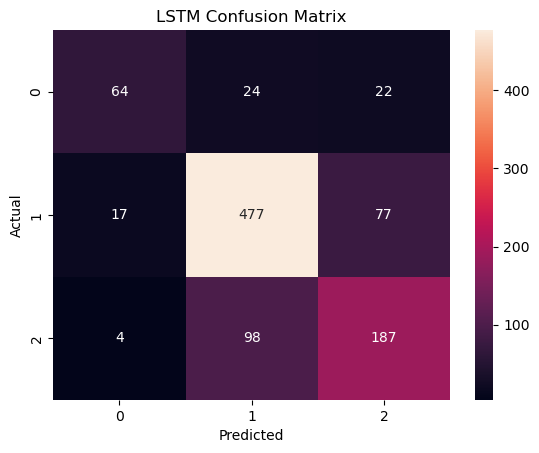

In [145]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_dl, y_pred_dl)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [168]:
# 9. Large Language Model (LLM) Integration

In [170]:
# 9.1 Install Gemini Package

In [147]:
!pip install -q google-generativeai


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [172]:
# 9.2 Gemini API setup

In [155]:
import google.generativeai as genai

genai.configure(api_key="API_KEY_REMOVED")

model = genai.GenerativeModel("models/gemini-2.5-flash")

In [ ]:
# 9.3 News Analysis using Gemini LLM

In [158]:
response = model.generate_content(
    "Gold price may increase due to global economic uncertainty.")
print(response.text)

That's a very common and historically observed relationship, and there's a strong rationale behind it. Here's why gold often acts as a "safe haven" asset during times of global economic uncertainty:

1.  **Safe Haven Asset:** When traditional investments like stocks and bonds become volatile or risky due to economic instability, investors tend to flock to assets perceived as safer. Gold has a long history as a store of value.

2.  **Hedge Against Inflation:** Economic uncertainty can often lead to concerns about inflation (governments potentially printing more money, supply chain disruptions, etc.). Gold is often seen as a hedge against inflation because its value tends to hold up better than fiat currencies during periods of rising prices.

3.  **Hedge Against Currency Devaluation:** If global economic uncertainty leads to a weakening of major currencies (like the US dollar or Euro), gold, which is priced globally, can become more attractive as an alternative store of wealth.

4.  **L

In [160]:
def analyze_news(news_text):
    response = model.generate_content(news_text)
    return response.text

In [162]:
sample_news = "Gold prices are expected to rise due to increasing geopolitical tensions."

result = analyze_news(sample_news)

print(result)

That's a very common and historically observed phenomenon. Here's why gold prices are often expected to rise due to increasing geopolitical tensions:

1.  **Safe-Haven Asset:** Gold is traditionally considered a "safe-haven" asset. When there's heightened uncertainty, market volatility, or a threat to economic stability due to geopolitical events (like military conflicts, trade wars, political instability in key regions, or diplomatic standoffs), investors tend to flock to assets perceived as reliable stores of value.

2.  **Uncertainty and Risk:** Geopolitical tensions create an environment of unpredictability. This encourages investors to move away from riskier assets like stocks, bonds, or even certain currencies that might be directly impacted by the conflict or instability. Gold, being a tangible asset with a long history as money, is seen as a way to preserve wealth during times of crisis.

3.  **Store of Value:** Unlike fiat currencies, which can be devalued by government action

In [174]:
#9.4 LSTM and Gemini Itegration

In [164]:
news = "Gold prices rise due to geopolitical tensions"

sentiment = "Positive"

prompt = f"""
News: {news}

Predicted Sentiment: {sentiment}

Explain how this news can affect gold prices.
"""

response = model.generate_content(prompt)

In [166]:
print(response.text)

This news directly illustrates a classic financial dynamic: **gold's role as a safe-haven asset during times of uncertainty.**

Here's a breakdown of how geopolitical tensions affect gold prices:

1.  **Increased Uncertainty:** Geopolitical tensions (conflicts, political instability, trade wars, etc.) create a high degree of uncertainty in global markets. Investors become worried about the stability of economies, currencies, and the performance of traditional assets like stocks and bonds.

2.  **Flight to Safety:** When uncertainty rises, investors tend to move their capital out of riskier assets (like stocks, which can be highly volatile) and into assets perceived as safer and more stable. Gold is traditionally seen as one of the ultimate safe havens.

3.  **Store of Value:** Gold has been a store of value for thousands of years. Unlike paper currencies, it cannot be printed into existence by governments, and its value is not tied to the performance of a specific company or economy. I

In [176]:
# 10. Project Conclusion

In [1]:
>>This project successfully combines LSTM-based sentiment analysis with Gemini LLM to analyze financial news
and explain its impact on gold prices. The LSTM model achieved an accuracy of approximately 75%, while 
Gemini provides detailed explanations that improve interpretability and decision-making. 
This approach helps users better understand the relationship between news sentiment and gold price movements.

SyntaxError: invalid syntax (3099951096.py, line 1)